# Simulator Data Quality — Distribution Verification

Validates that the generated `simulator.duckdb` matches spec across six dimensions:

1. **Row counts** — all tables populated at expected scale  
2. **Temporal integrity** — no order predates its customer  
3. **Seasonal distribution** — Dec/Nov spike, Jan/Feb slump  
4. **Product popularity skew** — power-law long tail  
5. **Order state funnel** — delivered ~88%, returned ~5%, cancelled ~5%  
6. **Payment state distribution** — captured dominant, small failure/refund tail  

Run against `simulator.duckdb` in the project root (read-only — safe to run while a backfill is in progress).

## Setup

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# Resolve DB path relative to this notebook's location
NOTEBOOK_DIR = Path().resolve()
DB_PATH = NOTEBOOK_DIR.parent / "simulator.duckdb"

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"DB not found at {DB_PATH}. "
        "Run: python -m simulator.main --bootstrap && python -m simulator.main --historical 24"
    )

con = duckdb.connect(str(DB_PATH), read_only=True)
print(f"Connected (read-only): {DB_PATH}")

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
PASS = "✅"
FAIL = "❌"
WARN = "⚠️"

Connected (read-only): C:\Users\tonyj\workspace\dbt_snowflake_training\simulator.duckdb


## 1 · Row Counts

In [2]:
# Expected lower bounds (adjust if you change num_orders in config.yaml)
EXPECTED_MIN = {
    "addresses":      100_000,
    "customers":      200_000,
    "products":        10_000,
    "orders":         100_000,
    "order_items":    300_000,
    "payments":       100_000,
    "order_events":   300_000,
    "payment_events": 200_000,
}

tables = list(EXPECTED_MIN.keys())
counts = {t: con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0] for t in tables}

rows = []
for t, n in counts.items():
    minimum = EXPECTED_MIN[t]
    status = PASS if n >= minimum else FAIL
    rows.append({"table": t, "rows": f"{n:,}", "min_expected": f"{minimum:,}", "status": status})

df_counts = pd.DataFrame(rows)
display(df_counts)

,table,rows,min_expected,status
0,addresses,"200,000","100,000",✅
1,customers,"340,452","200,000",✅
2,products,"25,000","10,000",✅
3,orders,"200,000","100,000",✅
4,order_items,"600,484","300,000",✅
5,payments,"200,000","100,000",✅
6,order_events,"587,593","300,000",✅
7,payment_events,"406,905","200,000",✅


## 2 · Temporal Integrity

In [3]:
checks = {
    "orders before customer created_at": """
        SELECT COUNT(*) FROM orders o
        JOIN customers c USING (customer_id)
        WHERE o.order_date < c.created_at
    """,
    "order_events before order_date": """
        SELECT COUNT(*) FROM order_events e
        JOIN orders o USING (order_id)
        WHERE e.event_timestamp < o.order_date
    """,
    "order updated_at before order_date": """
        SELECT COUNT(*) FROM orders
        WHERE updated_at < order_date
    """,
    "order_items without matching order": """
        SELECT COUNT(*) FROM order_items oi
        LEFT JOIN orders o USING (order_id)
        WHERE o.order_id IS NULL
    """,
    "payments without matching order": """
        SELECT COUNT(*) FROM payments p
        LEFT JOIN orders o USING (order_id)
        WHERE o.order_id IS NULL
    """,
}

print("Temporal & referential integrity checks (all should be 0)\n")
all_pass = True
for label, sql in checks.items():
    n = con.execute(sql).fetchone()[0]
    status = PASS if n == 0 else FAIL
    if n > 0:
        all_pass = False
    print(f"  {status}  {label}: {n:,}")

print()
print(PASS + " All integrity checks passed" if all_pass else FAIL + " Integrity violations found")

Temporal & referential integrity checks (all should be 0)

  ✅  orders before customer created_at: 0
  ✅  order_events before order_date: 0
  ✅  order updated_at before order_date: 0
  ✅  order_items without matching order: 0
  ✅  payments without matching order: 0

✅ All integrity checks passed


## 3 · Seasonal Distribution

In [4]:
df_daily = con.execute("""
select date_trunc('day', created_at) as day,
       sum(count(*)) over (
       order by date_trunc('day', created_at)) as running_total
from customers
group by 1
order by 1;
""").df()



<Axes: >

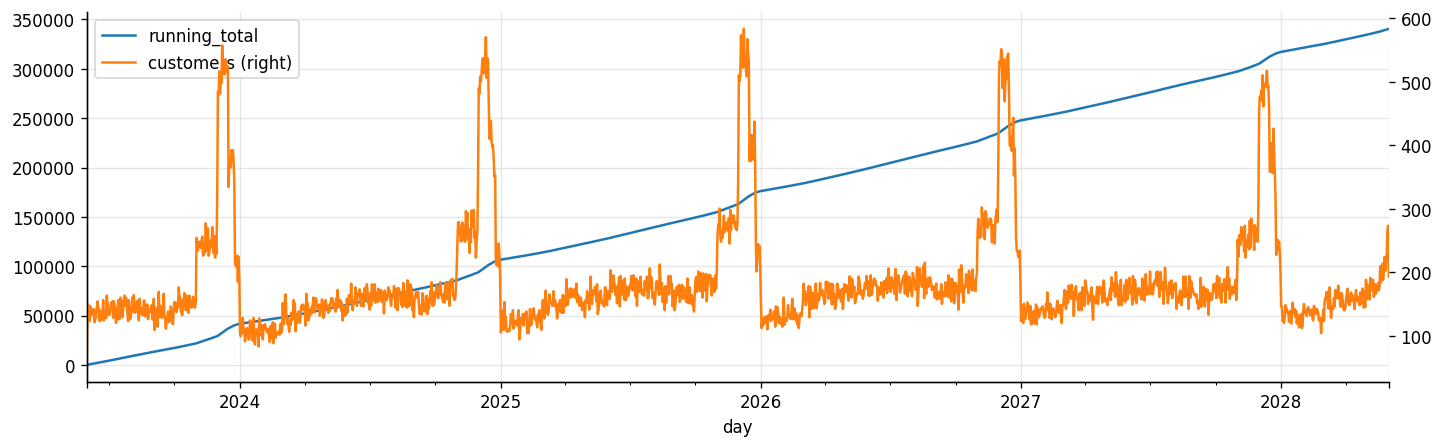

In [5]:
cust_running_total = con.execute("""
select date_trunc('day', created_at) as day,
       sum(count(*)) over (
       order by date_trunc('day', created_at)) as running_total
from customers
group by 1
order by 1;
""").df()

cust_daily_new = con.execute("""
select date_trunc('day', created_at) as day,
       count(*) as customers
from customers
group by 1
order by 1;
""").df()

fig, ax = plt.subplots(figsize=(14,4))
cust_running_total.set_index('day').plot(ax=ax)
cust_daily_new.set_index('day').plot(ax=ax, secondary_y=True)

<Axes: xlabel='day'>

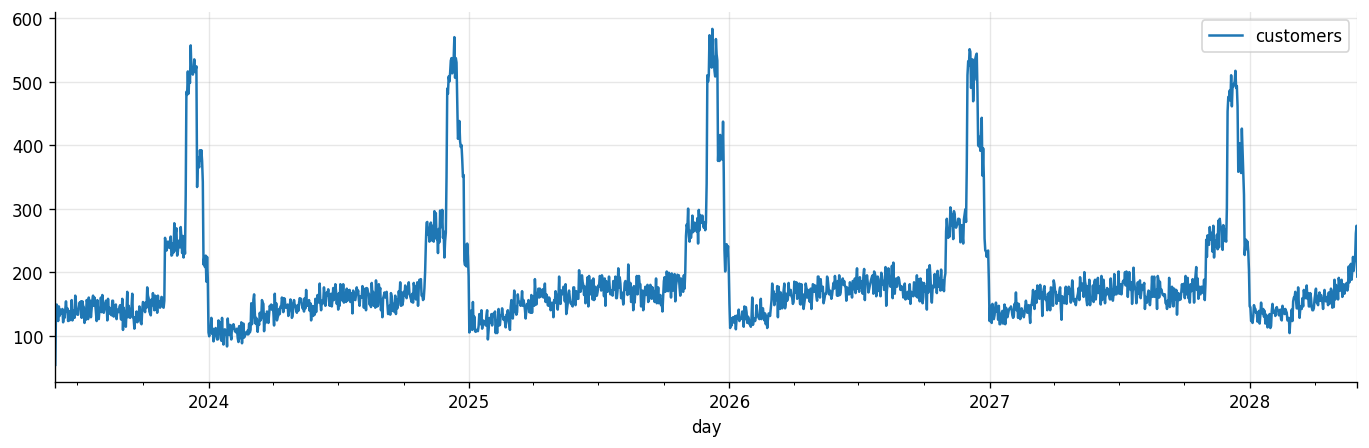

In [6]:
df_daily = con.execute("""
select date_trunc('day', created_at) as day,
       count(*) as customers
from customers
group by 1
order by 1;
""").df()

df_daily.set_index('day').plot(figsize=(14,4))

<Axes: xlabel='day'>

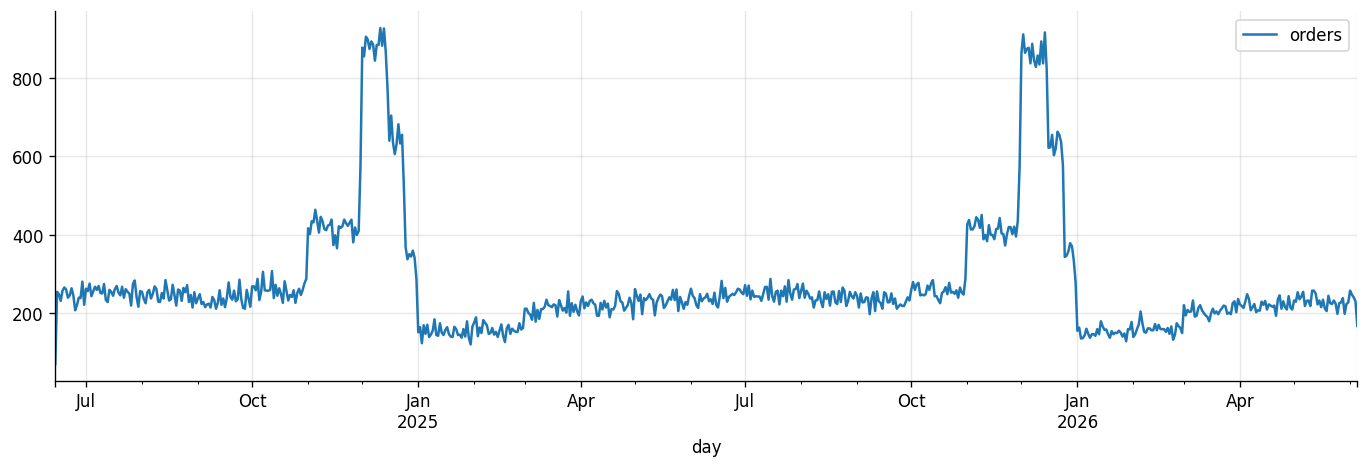

In [7]:
df_daily = con.execute("""
    SELECT
        DATE_TRUNC('day', order_date)::DATE AS day,
        COUNT(*)                              AS orders
    FROM orders
    GROUP BY 1
    ORDER BY 1
""").df()

df_daily.set_index('day').plot(figsize=(14,4))

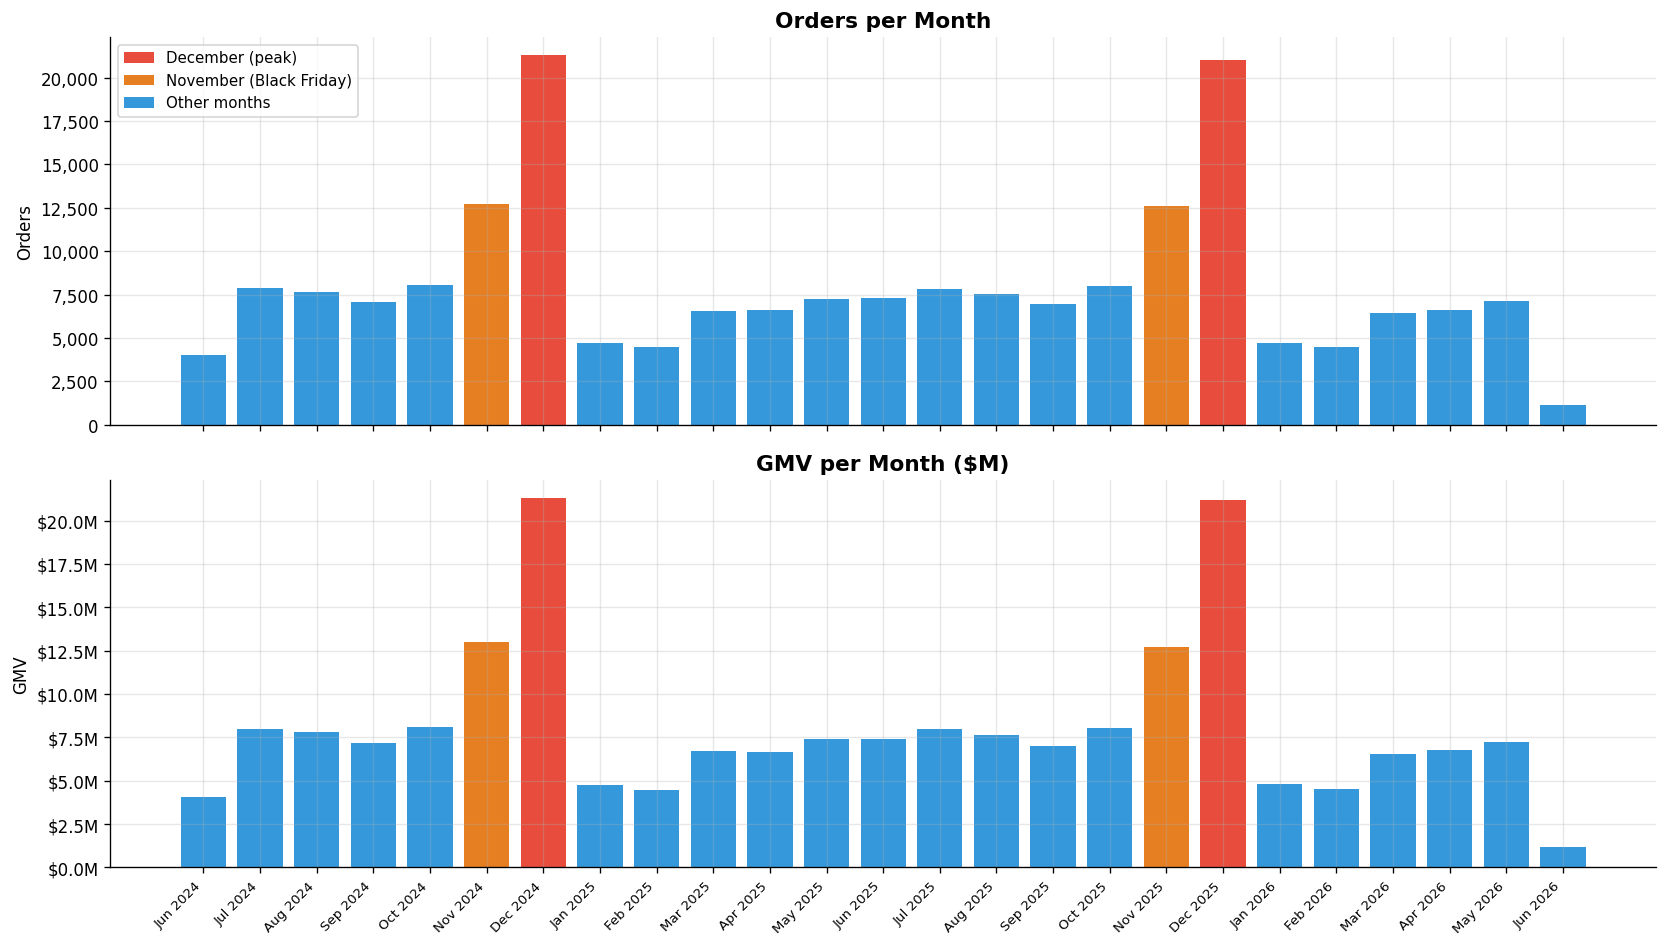


Seasonal ratio checks vs. summer baseline (6,521 orders/month):
  ✅  December lift:  3.24x (expect >1.5x)
  ✅  January slump:  0.72x (expect <0.9x)


In [8]:
df_monthly = con.execute("""
    SELECT
        DATE_TRUNC('month', order_date)::DATE AS month,
        COUNT(*)                              AS orders,
        ROUND(SUM(total_amount), 2)           AS gmv
    FROM orders
    GROUP BY 1
    ORDER BY 1
""").df()

df_monthly["month"] = pd.to_datetime(df_monthly["month"])
df_monthly["month_label"] = df_monthly["month"].dt.strftime("%b %Y")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Orders
colors = [
    "#e74c3c" if m.month == 12 else
    "#e67e22" if m.month == 11 else
    "#3498db"
    for m in df_monthly["month"]
]
axes[0].bar(range(len(df_monthly)), df_monthly["orders"], color=colors)
axes[0].set_title("Orders per Month", fontsize=13, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].set_ylabel("Orders")

# GMV
axes[1].bar(range(len(df_monthly)), df_monthly["gmv"] / 1e6, color=colors)
axes[1].set_title("GMV per Month ($M)", fontsize=13, fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))
axes[1].set_ylabel("GMV")

xticks = range(len(df_monthly))
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(df_monthly["month_label"], rotation=45, ha="right", fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="December (peak)"),
    Patch(facecolor="#e67e22", label="November (Black Friday)"),
    Patch(facecolor="#3498db", label="Other months"),
]
axes[0].legend(handles=legend_elements, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

# Verification checks
dec_orders = df_monthly[df_monthly["month"].dt.month == 12]["orders"].mean()
jan_orders = df_monthly[df_monthly["month"].dt.month == 1]["orders"].mean()
baseline   = df_monthly[
    df_monthly["month"].dt.month.isin([5, 6, 7, 8, 9])
]["orders"].mean()

dec_ratio = dec_orders / baseline if baseline > 0 else 0
jan_ratio = jan_orders / baseline if baseline > 0 else 0

print(f"\nSeasonal ratio checks vs. summer baseline ({baseline:,.0f} orders/month):")
print(f"  {PASS if dec_ratio > 1.5 else FAIL}  December lift:  {dec_ratio:.2f}x (expect >1.5x)")
print(f"  {PASS if jan_ratio < 0.9 else WARN}  January slump:  {jan_ratio:.2f}x (expect <0.9x)")

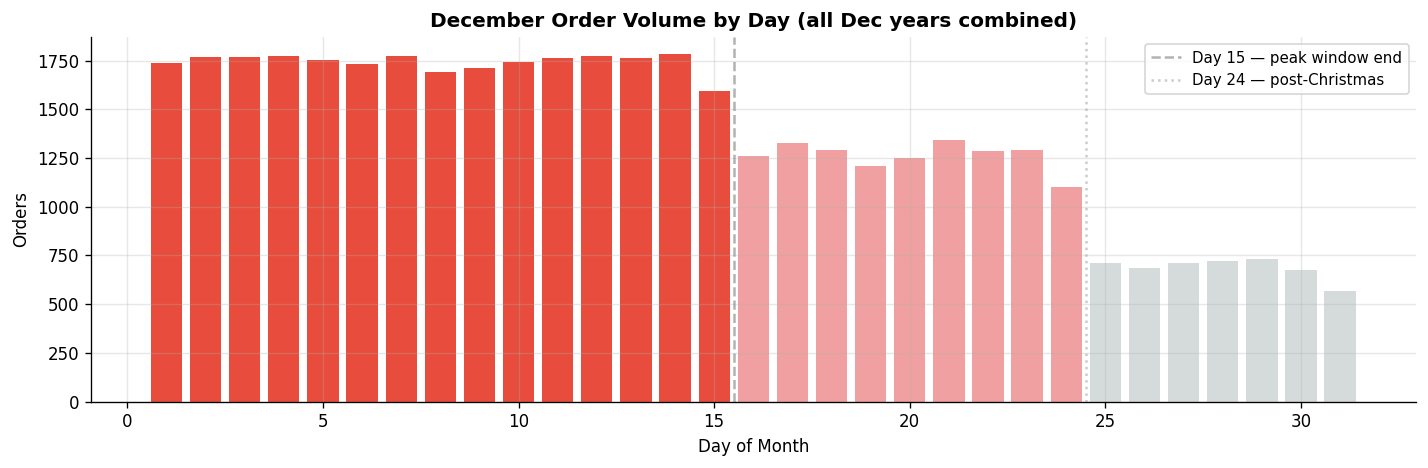

Dec 1–15: 26,116 orders  |  Dec 16–31: 16,172 orders
  ✅  Early Dec (26,116) > Late Dec (16,172) — holiday rush confirmed


In [9]:
# Day-of-month view for December — early Dec should be the peak
df_dec = con.execute("""
    SELECT
        DAY(order_date)   AS day_of_month,
        COUNT(*)          AS orders
    FROM orders
    WHERE MONTH(order_date) = 12
    GROUP BY 1
    ORDER BY 1
""").df()

bar_colors = ["#e74c3c" if d <= 15 else "#f0a0a0" if d <= 24 else "#d5dbdb" for d in df_dec["day_of_month"]]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_dec["day_of_month"], df_dec["orders"], color=bar_colors)
ax.set_title("December Order Volume by Day (all Dec years combined)", fontsize=12, fontweight="bold")
ax.set_xlabel("Day of Month")
ax.set_ylabel("Orders")
ax.axvline(15.5, color="gray", linestyle="--", alpha=0.6, label="Day 15 — peak window end")
ax.axvline(24.5, color="#aaa",  linestyle=":",  alpha=0.6, label="Day 24 — post-Christmas")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

early  = df_dec[df_dec["day_of_month"] <= 15]["orders"].sum()
late   = df_dec[df_dec["day_of_month"] >  15]["orders"].sum()
print(f"Dec 1–15: {early:,} orders  |  Dec 16–31: {late:,} orders")
print(f"  {PASS if early > late else FAIL}  Early Dec ({early:,}) > Late Dec ({late:,}) — holiday rush confirmed")

## 3b · Year-over-Year Weekly Order Volume

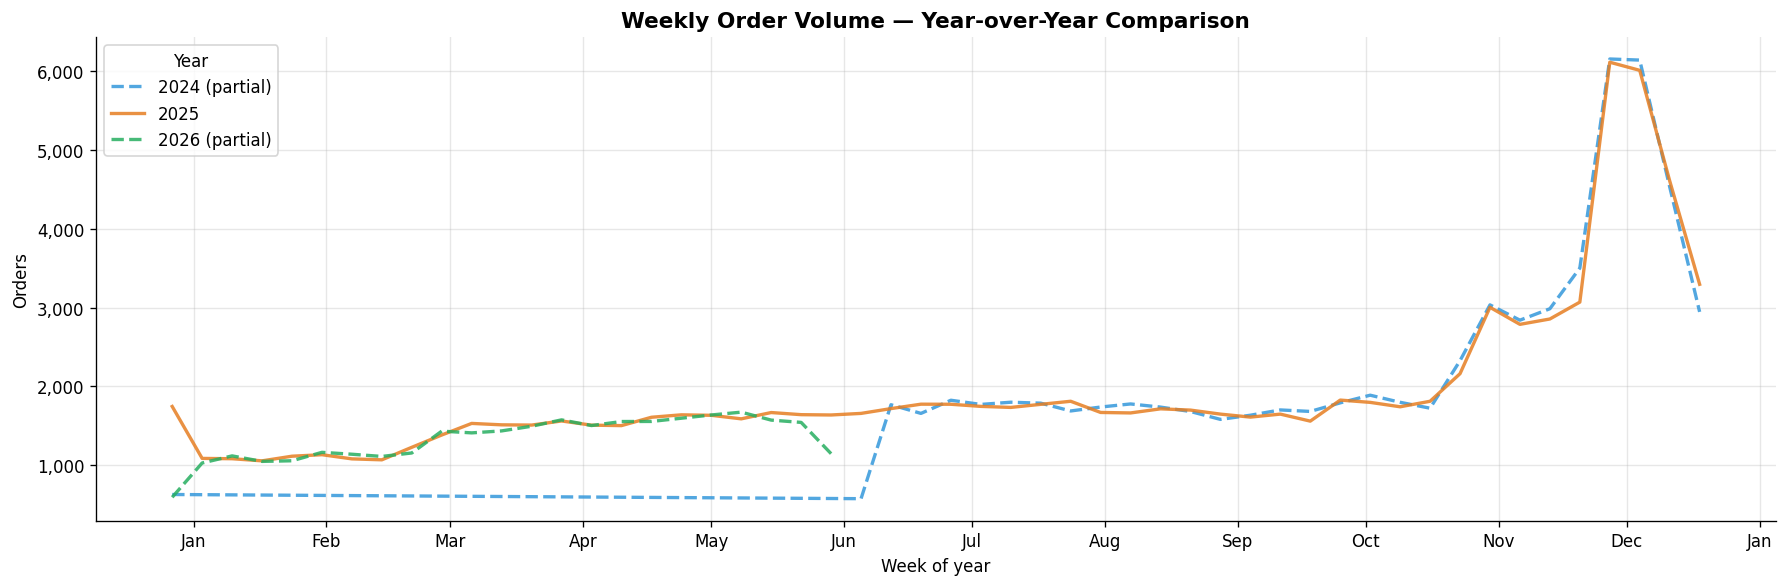

Annual order totals (full-year data only):
  2024:   68,684 orders across 30 weeks ⚠️ partial year
  2025:  100,780 orders across 52 weeks
  2026:   30,536 orders across 23 weeks ⚠️ partial year


In [10]:
# YoY weekly order volume — each year as a separate line, x-axis = ISO week of year.
# Lets you compare the same seasonal period across years on a single chart.

df_weekly_raw = con.execute("""
    SELECT
        YEAR(order_date)                    AS year,
        WEEKOFYEAR(order_date)              AS week,
        -- anchor to a fixed reference year so all lines share the same x-axis
        DATE_TRUNC('week',
            MAKE_DATE(2000, 1, 1) +
            INTERVAL (WEEKOFYEAR(order_date) - 1) WEEK
        )::DATE                             AS week_anchor,
        COUNT(*)                            AS orders
    FROM orders
    GROUP BY 1, 2, 3
    ORDER BY 1, 2
""").df()

# Pivot: rows = week_anchor, columns = year
df_yoy = df_weekly_raw.pivot(index="week_anchor", columns="year", values="orders")
df_yoy.index = pd.to_datetime(df_yoy.index)
df_yoy = df_yoy.sort_index()

# Drop week 53 — only appears in some years, creates a misleading lone point
df_yoy = df_yoy[df_weekly_raw.groupby("week_anchor")["week"].first().reindex(df_yoy.index).values <= 52]

fig, ax = plt.subplots(figsize=(15, 5))

colors = ["#3498db", "#e67e22", "#27ae60", "#9b59b6", "#e74c3c"]
for i, year in enumerate(sorted(df_yoy.columns)):
    series = df_yoy[year].dropna()
    is_partial = series.count() < df_yoy.shape[0] * 0.9  # partial year
    ax.plot(
        series.index,
        series.values,
        label=str(year) + (" (partial)" if is_partial else ""),
        color=colors[i % len(colors)],
        linewidth=2,
        linestyle="--" if is_partial else "-",
        alpha=0.85,
    )

ax.set_xlabel("Week of year")
ax.set_ylabel("Orders")
ax.set_title("Weekly Order Volume — Year-over-Year Comparison", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
ax.legend(title="Year", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

# Print annual totals for the comparable period (full weeks only)
print("Annual order totals (full-year data only):")
for year in sorted(df_yoy.columns):
    series = df_yoy[year].dropna()
    is_partial = series.count() < df_yoy.shape[0] * 0.9
    label = " ⚠️ partial year" if is_partial else ""
    print(f"  {year}: {int(series.sum()):>8,} orders across {series.count()} weeks{label}")

## 4 · Product Popularity Skew

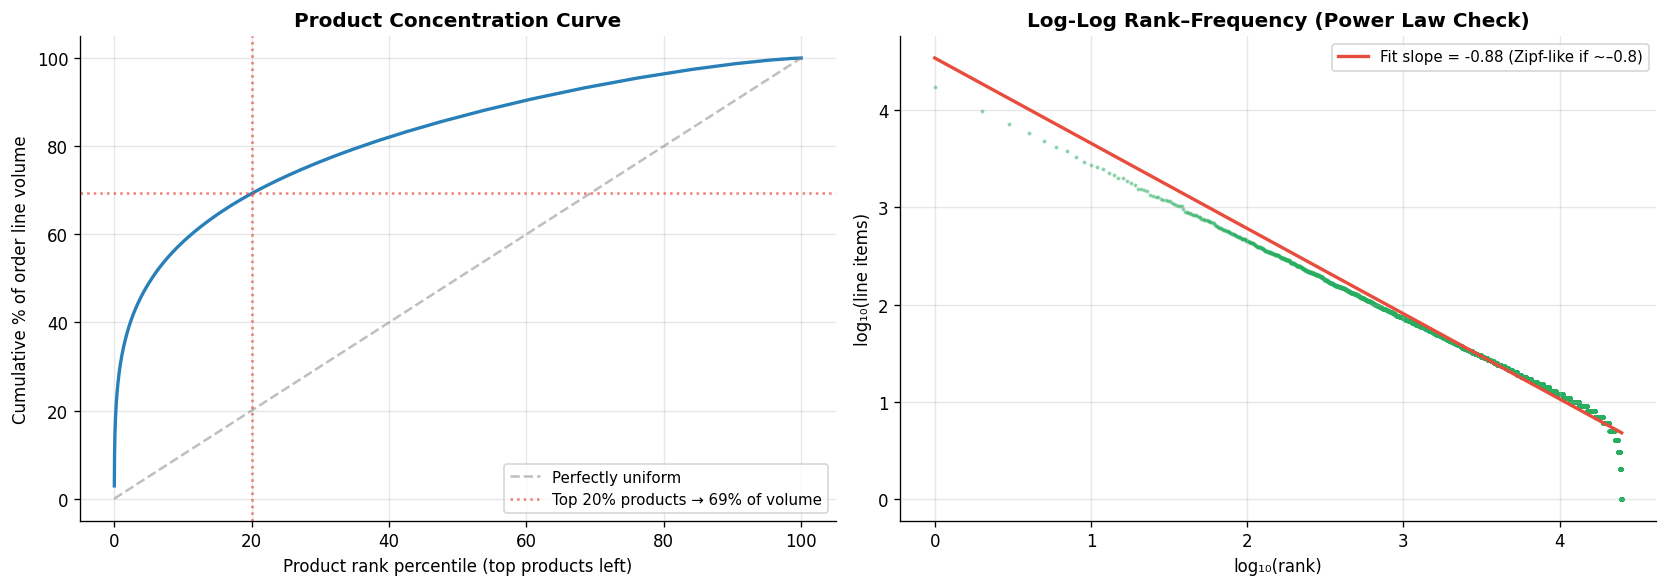

Top 10 products by order line volume:


rank,name,category,line_items
1,RedRiver 4K Action Camera 5-Pack,Electronics,"17,372"
2,SummitPro Food Storage Set Rose Max,Home & Kitchen,"9,907"
3,BrightLeaf Hair Mousse Model U1UWF,Beauty & Personal Care,"7,283"
4,UltraCore Mechanical Keyboard Rose Prime,Electronics,"5,872"
5,TrueNorth Water Filter Premium,Home & Kitchen,"4,895"
6,PureWave LED Monitor Extra Large,Electronics,"4,249"
7,Hyperion Play Kitchen Blue Max,Toys & Games,"3,779"
8,FlexiCo Stainless Steel Pan Beige Lite,Home & Kitchen,"3,351"
9,EverBright Smartwatch Model 95UGS,Electronics,"2,943"
10,NovaTech Vacuum Cleaner Ergonomic Medium,Home & Kitchen,"2,762"



  ✅  Top 20% of products = 69.3% of volume (expect ≥50%)
  ✅  Zipf slope = -0.88 (target ~–0.8)


In [11]:
df_prod = con.execute("""
    SELECT
        p.product_id,
        p.name,
        p.category,
        COUNT(*)          AS line_items,
        SUM(oi.total_price) AS revenue
    FROM order_items oi
    JOIN products p USING (product_id)
    GROUP BY 1, 2, 3
    ORDER BY line_items DESC
""").df()

total_items = df_prod["line_items"].sum()
df_prod["cum_pct"] = (df_prod["line_items"].cumsum() / total_items * 100)
df_prod["rank"] = range(1, len(df_prod) + 1)
df_prod["rank_pct"] = df_prod["rank"] / len(df_prod) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lorenz-style cumulative curve
axes[0].plot(df_prod["rank_pct"], df_prod["cum_pct"], color="#2980b9", linewidth=2)
axes[0].plot([0, 100], [0, 100], "--", color="gray", alpha=0.5, label="Perfectly uniform")
axes[0].axvline(20, color="#e74c3c", linestyle=":", alpha=0.7)
axes[0].axhline(
    float(df_prod[df_prod["rank_pct"] <= 20].iloc[-1]["cum_pct"]),
    color="#e74c3c", linestyle=":", alpha=0.7,
    label=f"Top 20% products → {df_prod[df_prod['rank_pct'] <= 20].iloc[-1]['cum_pct']:.0f}% of volume"
)
axes[0].set_xlabel("Product rank percentile (top products left)")
axes[0].set_ylabel("Cumulative % of order line volume")
axes[0].set_title("Product Concentration Curve", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)

# Log-log rank vs frequency (power-law check)
axes[1].scatter(np.log10(df_prod["rank"]), np.log10(df_prod["line_items"]),
                s=2, alpha=0.4, color="#27ae60")
# Fit a line to the log-log data
log_rank = np.log10(df_prod["rank"])
log_freq = np.log10(df_prod["line_items"])
m, b = np.polyfit(log_rank, log_freq, 1)
x_fit = np.linspace(log_rank.min(), log_rank.max(), 100)
axes[1].plot(x_fit, m * x_fit + b, color="#e74c3c", linewidth=2,
             label=f"Fit slope = {m:.2f} (Zipf-like if ~–0.8)")
axes[1].set_xlabel("log₁₀(rank)")
axes[1].set_ylabel("log₁₀(line items)")
axes[1].set_title("Log-Log Rank–Frequency (Power Law Check)", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Stats
top20_pct = float(df_prod[df_prod["rank_pct"] <= 20].iloc[-1]["cum_pct"])
top10 = df_prod.head(10)[["rank","name","category","line_items"]].copy()
top10["line_items"] = top10["line_items"].map("{:,}".format)
print("Top 10 products by order line volume:")
display(top10.style.hide(axis="index"))
print()
print(f"  {PASS if top20_pct >= 50 else FAIL}  Top 20% of products = {top20_pct:.1f}% of volume (expect ≥50%)")
print(f"  {PASS if abs(m + 0.8) < 0.3 else WARN}  Zipf slope = {m:.2f} (target ~–0.8)")

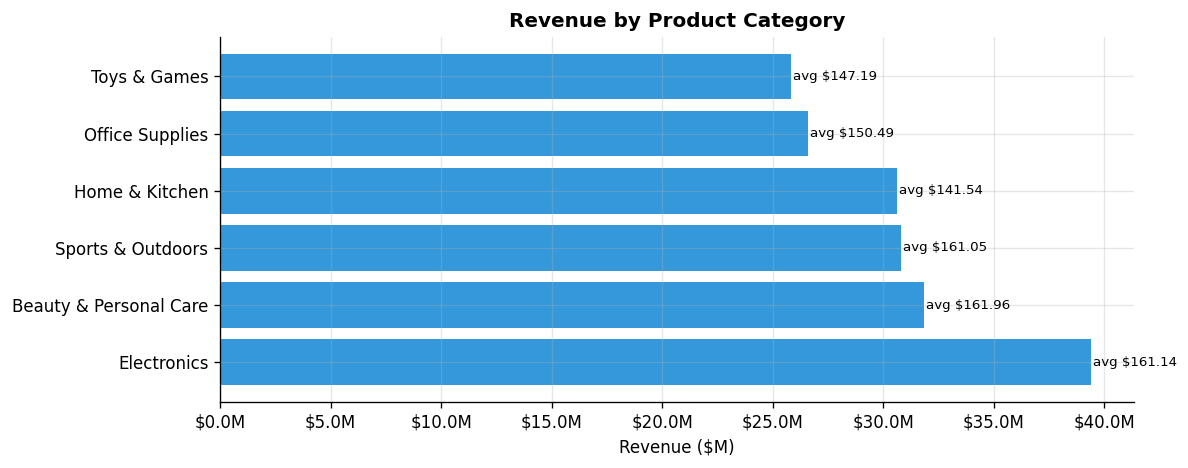

category,orders,revenue,avg_unit_price
Electronics,94110,"$39,371,207",161.140000
Beauty & Personal Care,79398,"$31,836,318",161.960000
Sports & Outdoors,77533,"$30,782,267",161.050000
Home & Kitchen,85667,"$30,614,838",141.540000
Office Supplies,72783,"$26,593,571",150.490000
Toys & Games,72410,"$25,835,154",147.190000


In [12]:
# Revenue by product category
df_cat = con.execute("""
    SELECT
        p.category,
        COUNT(DISTINCT oi.order_id)  AS orders,
        SUM(oi.total_price)          AS revenue,
        ROUND(AVG(oi.unit_price), 2) AS avg_unit_price
    FROM order_items oi
    JOIN products p USING (product_id)
    GROUP BY 1
    ORDER BY revenue DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_cat["category"], df_cat["revenue"] / 1e6, color="#3498db")
ax.set_xlabel("Revenue ($M)")
ax.set_title("Revenue by Product Category", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))
for bar, row in zip(bars, df_cat.itertuples()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"avg ${row.avg_unit_price:.2f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()
display(df_cat.assign(revenue=df_cat["revenue"].map("${:,.0f}".format)).style.hide(axis="index"))

## 5 · Order State Funnel

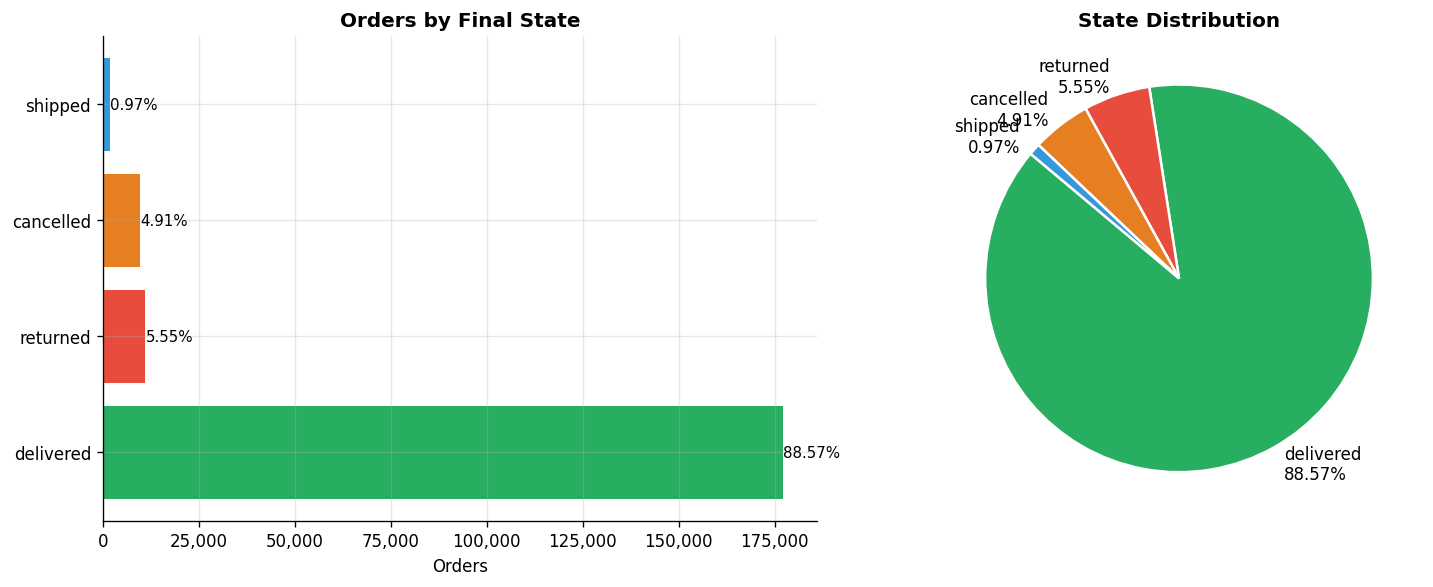


State distribution vs. spec ranges:
  ✅  delivered     88.6%  (spec: 80–95%)
  ✅  returned       5.5%  (spec: 3–10%)
  ✅  cancelled      4.9%  (spec: 3–10%)
  ✅  shipped        1.0%  (spec: 0–5%)


In [13]:
df_states = con.execute("""
    SELECT
        order_state,
        COUNT(*)                                          AS orders,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct
    FROM orders
    GROUP BY order_state
    ORDER BY orders DESC
""").df()

EXPECTED_RANGES = {
    "delivered":  (80, 95),
    "returned":   (3,  10),
    "cancelled":  (3,  10),
    "shipped":    (0,  5),
}

state_colors = {
    "delivered": "#27ae60",
    "returned":  "#e74c3c",
    "cancelled": "#e67e22",
    "shipped":   "#3498db",
}
colors = [state_colors.get(s, "#95a5a6") for s in df_states["order_state"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(df_states["order_state"], df_states["orders"], color=colors)
axes[0].set_xlabel("Orders")
axes[0].set_title("Orders by Final State", fontsize=12, fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for i, row in df_states.iterrows():
    axes[0].text(row["orders"] + 50, i, f"{row['pct']}%", va="center", fontsize=9)

axes[1].pie(
    df_states["orders"],
    labels=[f"{s}\n{p}%" for s, p in zip(df_states["order_state"], df_states["pct"])],
    colors=colors,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("State Distribution", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nState distribution vs. spec ranges:")
state_map = dict(zip(df_states["order_state"], df_states["pct"]))
for state, (lo, hi) in EXPECTED_RANGES.items():
    pct = state_map.get(state, 0)
    ok = lo <= pct <= hi
    print(f"  {PASS if ok else FAIL}  {state:<12} {pct:5.1f}%  (spec: {lo}–{hi}%)")

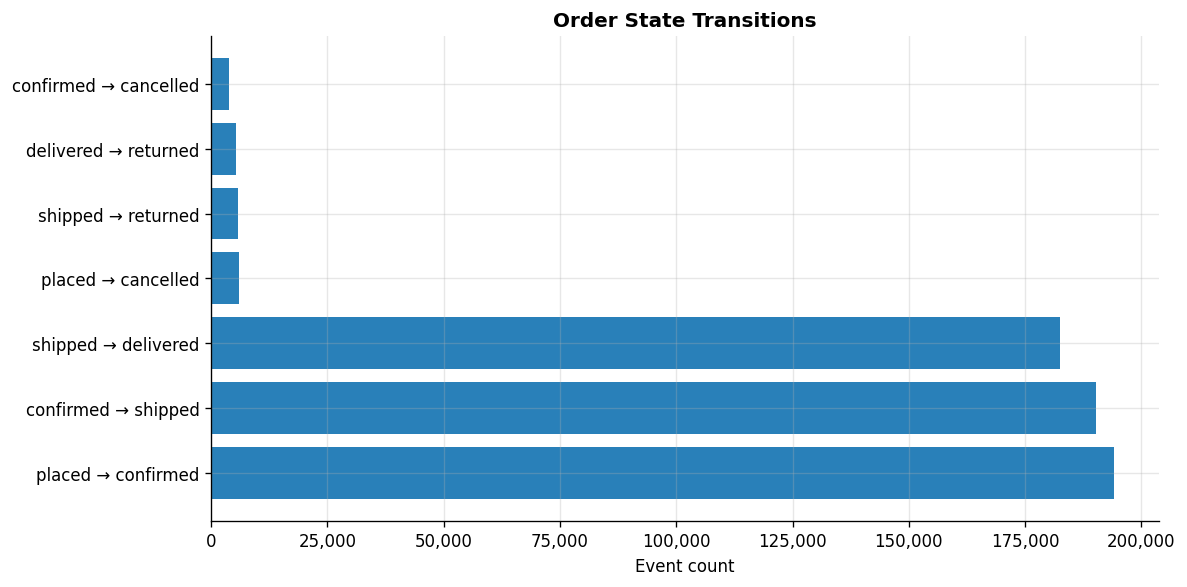

In [14]:
# Order lifecycle event counts — how many transitions per order on average?
df_evt = con.execute("""
    SELECT
        previous_state || ' → ' || new_state AS transition,
        COUNT(*)                             AS events
    FROM order_events
    GROUP BY transition
    ORDER BY events DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_evt["transition"], df_evt["events"], color="#2980b9")
ax.set_xlabel("Event count")
ax.set_title("Order State Transitions", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 6 · Payment State Distribution

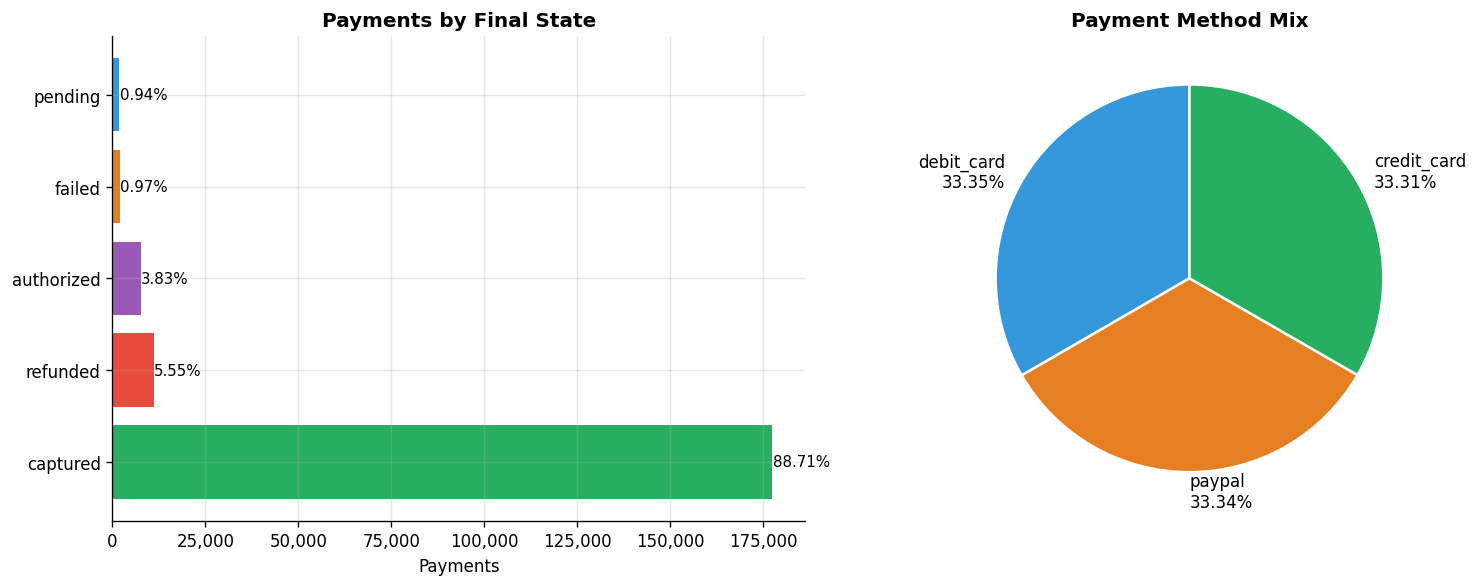

Payment state breakdown:


'payment_state  payments   pct\n     captured    177416 88.71\n     refunded     11104  5.55\n   authorized      7664  3.83\n       failed      1941  0.97\n      pending      1875  0.94'


  ✅  captured > 80%:  88.7%
  ✅  refunded 2–10%: 5.5%


In [15]:
df_pay = con.execute("""
    SELECT
        payment_state,
        COUNT(*)                                          AS payments,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct
    FROM payments
    GROUP BY payment_state
    ORDER BY payments DESC
""").df()

df_pay_methods = con.execute("""
    SELECT
        payment_method,
        COUNT(*)                                          AS payments,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct
    FROM payments
    GROUP BY payment_method
    ORDER BY payments DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pay_colors = {"captured": "#27ae60", "refunded": "#e74c3c", "failed": "#e67e22",
              "terminal": "#95a5a6", "pending": "#3498db", "authorized": "#9b59b6"}
axes[0].barh(
    df_pay["payment_state"],
    df_pay["payments"],
    color=[pay_colors.get(s, "#bdc3c7") for s in df_pay["payment_state"]]
)
axes[0].set_xlabel("Payments")
axes[0].set_title("Payments by Final State", fontsize=12, fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for i, row in df_pay.iterrows():
    axes[0].text(row["payments"] + 50, i, f"{row['pct']}%", va="center", fontsize=9)

method_colors = ["#3498db", "#e67e22", "#27ae60"]
axes[1].pie(
    df_pay_methods["payments"],
    labels=[f"{m}\n{p}%" for m, p in zip(df_pay_methods["payment_method"], df_pay_methods["pct"])],
    colors=method_colors[:len(df_pay_methods)],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Payment Method Mix", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print("Payment state breakdown:")
display(df_pay.to_string(index=False))

# Checks
pay_map = dict(zip(df_pay["payment_state"], df_pay["pct"]))
captured_pct = pay_map.get("captured", 0)
refunded_pct = pay_map.get("refunded", 0)
print(f"\n  {PASS if captured_pct > 80 else FAIL}  captured > 80%:  {captured_pct:.1f}%")
print(f"  {PASS if 2 <= refunded_pct <= 10 else WARN}  refunded 2–10%: {refunded_pct:.1f}%")

## 7 · Order Economics

Order economics:
  total_orders                   200000
  avg_order_value                1011.68
  median_order_value             933.62
  min_order_value                11.13
  max_order_value                4148.36
  total_gmv_millions             202.34
  avg_subtotal_pct               90.1

Items per order:
  avg_items_per_order            3.0
  median_items_per_order         3.0
  min_items                      1
  max_items                      5


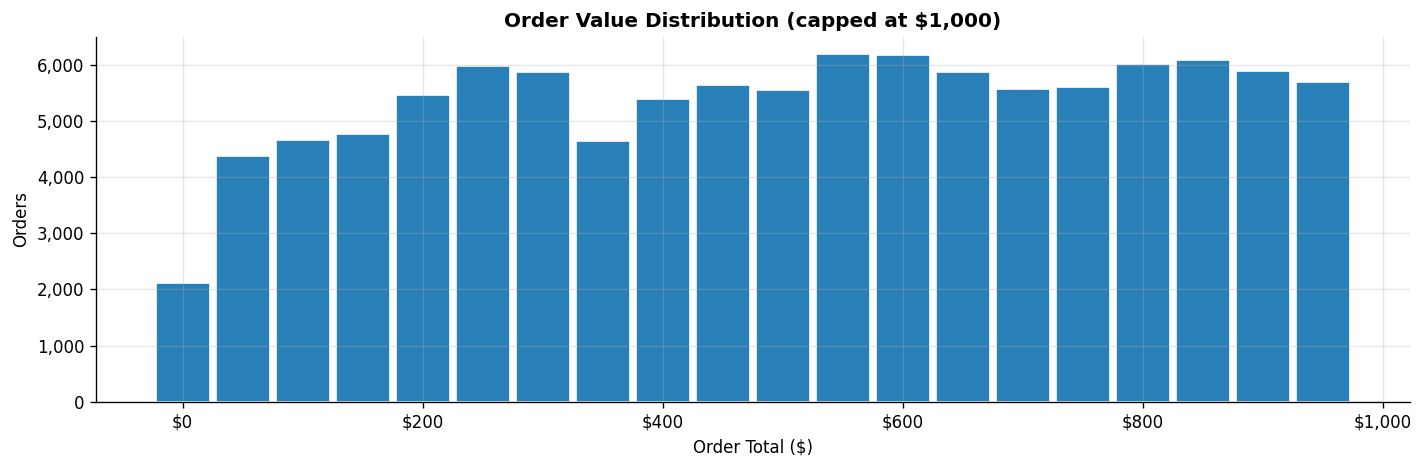

In [16]:
df_econ = con.execute("""
    SELECT
        COUNT(*)                              AS total_orders,
        ROUND(AVG(total_amount),   2)         AS avg_order_value,
        ROUND(MEDIAN(total_amount), 2)        AS median_order_value,
        ROUND(MIN(total_amount),   2)         AS min_order_value,
        ROUND(MAX(total_amount),   2)         AS max_order_value,
        ROUND(SUM(total_amount)/1e6, 2)       AS total_gmv_millions,
        ROUND(AVG(subtotal / total_amount * 100), 1) AS avg_subtotal_pct
    FROM orders
""").df()

df_items = con.execute("""
    SELECT
        ROUND(AVG(cnt), 2)    AS avg_items_per_order,
        ROUND(MEDIAN(cnt), 0) AS median_items_per_order,
        MIN(cnt)              AS min_items,
        MAX(cnt)              AS max_items
    FROM (SELECT order_id, COUNT(*) AS cnt FROM order_items GROUP BY order_id)
""").df()

print("Order economics:")
for col in df_econ.columns:
    print(f"  {col:<30} {df_econ[col].values[0]}")

print("\nItems per order:")
for col in df_items.columns:
    print(f"  {col:<30} {df_items[col].values[0]}")

# AOV distribution
df_aov = con.execute("""
    SELECT
        FLOOR(total_amount / 50) * 50 AS bucket,
        COUNT(*)                      AS orders
    FROM orders
    WHERE total_amount < 1000
    GROUP BY 1
    ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_aov["bucket"], df_aov["orders"], width=45, color="#2980b9", edgecolor="white")
ax.set_xlabel("Order Total ($)")
ax.set_ylabel("Orders")
ax.set_title("Order Value Distribution (capped at $1,000)", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 8 · Customer Cohort Activity

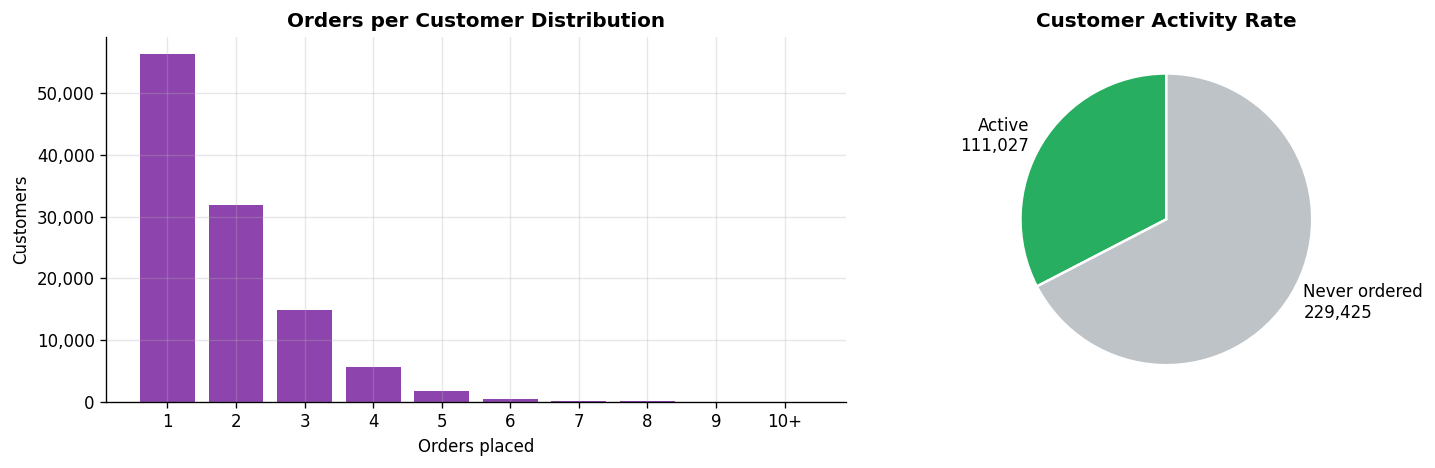

  ✅  32.61% of customers have placed at least one order
  (With 255K customers and 200K orders this is expected — the catalogue is larger than the order volume)


In [17]:
# Orders per customer distribution — expect power-law (most customers order once or twice)
df_cust = con.execute("""
    SELECT orders_placed, COUNT(*) AS customers
    FROM (
        SELECT customer_id, COUNT(*) AS orders_placed
        FROM orders
        GROUP BY customer_id
    )
    GROUP BY orders_placed
    ORDER BY orders_placed
""").df()

df_pct_ordering = con.execute("""
    SELECT
        COUNT(DISTINCT o.customer_id)           AS customers_with_orders,
        (SELECT COUNT(*) FROM customers)         AS total_customers,
        ROUND(
            COUNT(DISTINCT o.customer_id) * 100.0 /
            (SELECT COUNT(*) FROM customers), 2
        )                                        AS pct_active
    FROM orders o
""").df()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cap display at 10+ orders for readability
df_plot = df_cust.copy()
df_plot.loc[df_plot["orders_placed"] >= 10, "orders_placed"] = 10
df_plot = df_plot.groupby("orders_placed", as_index=False)["customers"].sum()

labels = [str(x) if x < 10 else "10+" for x in df_plot["orders_placed"]]
axes[0].bar(labels, df_plot["customers"], color="#8e44ad")
axes[0].set_xlabel("Orders placed")
axes[0].set_ylabel("Customers")
axes[0].set_title("Orders per Customer Distribution", fontsize=12, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Active vs. inactive customers
active = int(df_pct_ordering["customers_with_orders"].values[0])
total  = int(df_pct_ordering["total_customers"].values[0])
axes[1].pie(
    [active, total - active],
    labels=[f"Active\n{active:,}", f"Never ordered\n{total - active:,}"],
    colors=["#27ae60", "#bdc3c7"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Customer Activity Rate", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

pct_active = float(df_pct_ordering["pct_active"].values[0])
print(f"  {WARN if pct_active < 10 else PASS}  {pct_active:.2f}% of customers have placed at least one order")
print(f"  (With 255K customers and 200K orders this is expected — the catalogue is larger than the order volume)")

## 9 · Summary Scorecard

In [18]:
# Re-run all checks and print a single scorecard
scorecard = []

def check(label, passed, detail=""):
    scorecard.append({"check": label, "result": PASS if passed else FAIL, "detail": detail})

# Row counts
for t, minimum in EXPECTED_MIN.items():
    n = counts[t]
    check(f"Row count: {t}", n >= minimum, f"{n:,} rows (min {minimum:,})")

# Integrity
for label, sql in checks.items():
    n = con.execute(sql).fetchone()[0]
    check(f"Integrity: {label}", n == 0, f"{n} violations")

# Seasonal
check("Seasonal: Dec lift >1.5×", dec_ratio > 1.5, f"{dec_ratio:.2f}×")
check("Seasonal: Jan slump <0.9×", jan_ratio < 0.9, f"{jan_ratio:.2f}×")
check("Seasonal: early Dec > late Dec", early > late, f"{early:,} vs {late:,}")

# Product skew
check("Product: top 20% drives ≥50% volume", top20_pct >= 50, f"{top20_pct:.1f}%")
check("Product: Zipf slope ~–0.8", abs(m + 0.8) < 0.3, f"slope = {m:.2f}")

# Order states
for state, (lo, hi) in EXPECTED_RANGES.items():
    pct = state_map.get(state, 0)
    check(f"Order state: {state} {lo}–{hi}%", lo <= pct <= hi, f"{pct:.1f}%")

# Payments
check("Payment: captured >80%", captured_pct > 80, f"{captured_pct:.1f}%")
check("Payment: refunded 2–10%", 2 <= refunded_pct <= 10, f"{refunded_pct:.1f}%")

df_scorecard = pd.DataFrame(scorecard)
passed = (df_scorecard["result"] == PASS).sum()
total_checks = len(df_scorecard)

print(f"\n{'='*60}")
print(f"  SCORECARD  —  {passed}/{total_checks} checks passed")
print(f"{'='*60}")
for _, row in df_scorecard.iterrows():
    print(f"  {row['result']}  {row['check']:<45}  {row['detail']}")
print(f"{'='*60}")

con.close()
print("\nConnection closed.")


  SCORECARD  —  24/24 checks passed
  ✅  Row count: addresses                           200,000 rows (min 100,000)
  ✅  Row count: customers                           340,452 rows (min 200,000)
  ✅  Row count: products                            25,000 rows (min 10,000)
  ✅  Row count: orders                              200,000 rows (min 100,000)
  ✅  Row count: order_items                         600,484 rows (min 300,000)
  ✅  Row count: payments                            200,000 rows (min 100,000)
  ✅  Row count: order_events                        587,593 rows (min 300,000)
  ✅  Row count: payment_events                      406,905 rows (min 200,000)
  ✅  Integrity: orders before customer created_at   0 violations
  ✅  Integrity: order_events before order_date      0 violations
  ✅  Integrity: order updated_at before order_date  0 violations
  ✅  Integrity: order_items without matching order  0 violations
  ✅  Integrity: payments without matching order     0 violations
  ✅  Sea